<a href="https://colab.research.google.com/github/chaudhary-dotcom/DeepLearning/blob/main/dl_BatchNormaalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
df = pd.read_csv(r'/content/concertriccir2.csv')

df.head()

,7.003345706103683010e-01,-2.470675778972781789e-01,0.000000000000000000e+00
0,-3.950019,2.740080,1.0
1,0.150222,-2.157638,1.0
2,-1.672050,-0.941519,1.0
3,2.560483,-1.846577,1.0
4,-1.724979,3.463930,1.0


In [12]:
df.columns = ['X', 'y', 'target']

df.head()

,X,y,target
0,-3.950019,2.740080,1.0
1,0.150222,-2.157638,1.0
2,-1.672050,-0.941519,1.0
3,2.560483,-1.846577,1.0
4,-1.724979,3.463930,1.0


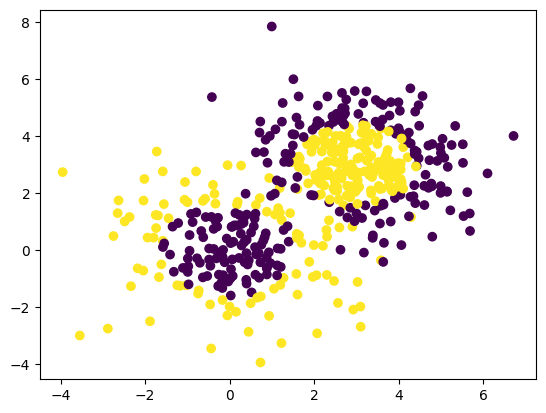

In [15]:
plt.scatter(df['X'], df['y'], c=df['target'])

In [16]:
df.shape

(499, 3)

In [19]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [21]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization

## without using batch normalization

In [25]:
model = Sequential()

model.add(Dense(2,activation='relu', input_dim=2))
model.add(Dense(2,activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


In [27]:
history1 = model.fit(X,y,epochs=200, validation_split=0.2)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5414 - loss: 0.7645 - val_accuracy: 0.5000 - val_loss: 0.6823
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5539 - loss: 0.7605 - val_accuracy: 0.5000 - val_loss: 0.6836
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5464 - loss: 0.7566 - val_accuracy: 0.5000 - val_loss: 0.6846
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5439 - loss: 0.7533 - val_accuracy: 0.5000 - val_loss: 0.6856
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5414 - loss: 0.7499 - val_accuracy: 0.5000 - val_loss: 0.6864
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5363 - loss: 0.7469 - val_accuracy: 0.5000 - val_loss: 0.6876
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5338 - loss: 0.7439 - val_accuracy: 0.4900 - val_loss: 0.6886
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5263 - loss: 0.7412 - val_accuracy: 0.4900 - 

## Using Batch Normalization

In [29]:
model = Sequential()

model.add(Dense(3, activation='relu', input_dim=2))
model.add(BatchNormalization())
model.add(Dense(2, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3)              │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2)              │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 10 (40.00 B)

In [30]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [31]:
history2 = model.fit(X,y,epochs=200, validation_split=0.2)


Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5439 - loss: 0.8007 - val_accuracy: 0.5600 - val_loss: 1.0392
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5414 - loss: 0.7985 - val_accuracy: 0.5500 - val_loss: 1.0030
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5363 - loss: 0.7952 - val_accuracy: 0.5400 - val_loss: 0.9765
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5388 - loss: 0.7894 - val_accuracy: 0.5100 - val_loss: 0.9591
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5539 - loss: 0.7682 - val_accuracy: 0.5100 - val_loss: 0.9416
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5664 - loss: 0.7627 - val_accuracy: 0.5200 - val_loss: 0.9265
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5338 - loss: 0.7667 - val_accuracy: 0.5000 - val_loss: 0.9127
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5614 - loss: 0.7401 - val_accuracy: 0.4800

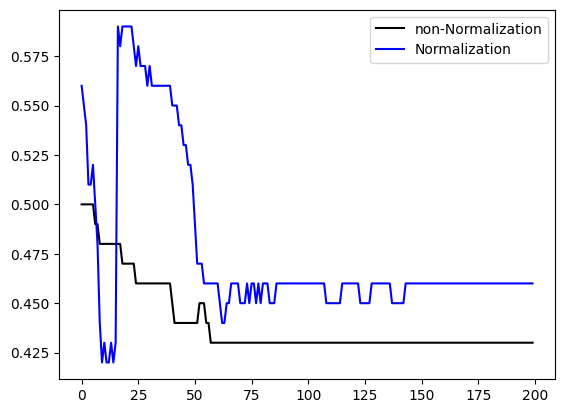

In [38]:
plt.plot(history1.history['val_accuracy'], color='black', label='non-Normalization')
plt.plot(history2.history['val_accuracy'], color='blue', label='Normalization')
plt.legend()

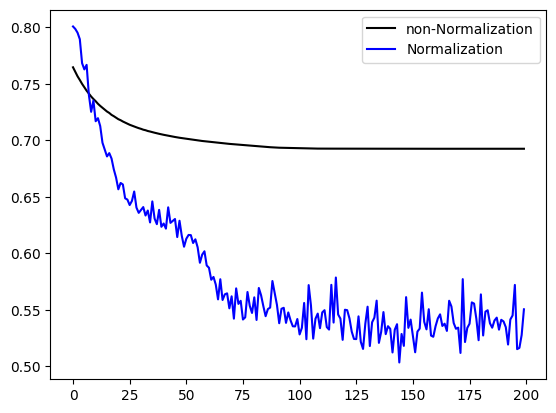

In [36]:
plt.plot(history1.history['loss'], color='black', label='non-Normalization')
plt.plot(history2.history['loss'], color='blue', label='Normalization')
plt.legend()